In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 6, 50).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.3, size=X.shape[0])

In [4]:
# Split it into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

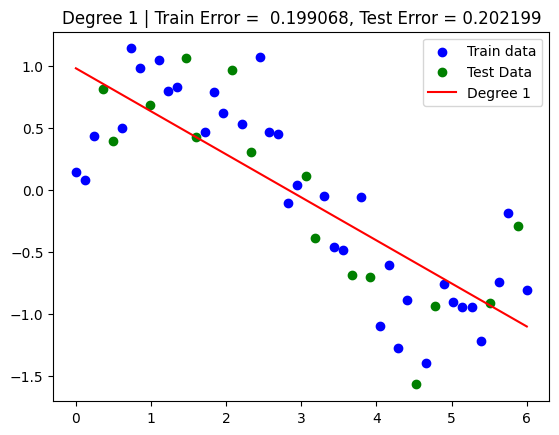

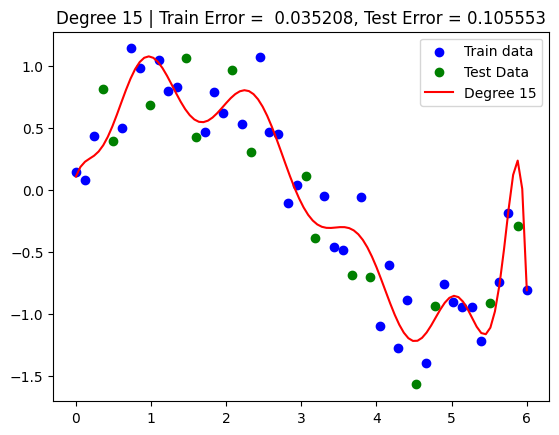

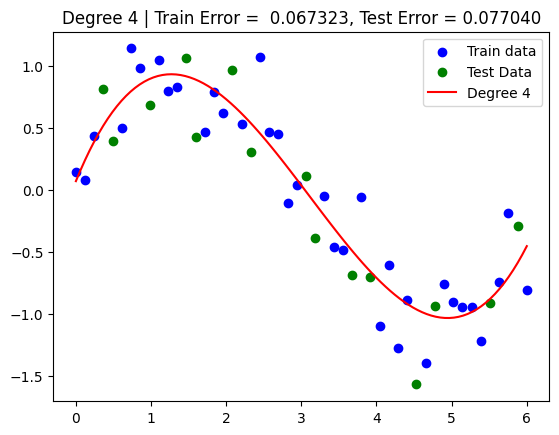

In [5]:
def plot_model(degree):
    # create polynomial Features    
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit regression model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    # Plot
    plt.scatter(X_train, y_train, color="blue", label="Train data")
    plt.scatter(X_test, y_test, color="green", label="Test Data")
    X_curve = np.linspace(0, 6, 100).reshape(-1, 1)
    plt.plot(X_curve, model.predict(poly.transform(X_curve)), color="red", label=f"Degree {degree}")
    plt.title(f"Degree {degree} | Train Error = {train_error: 3f}, Test Error = {test_error:3f}")
    plt.legend()
    plt.show()


# Try with different complexities
plot_model(1)       # High bias (underfitting)
plot_model(15)      # High variance (Overfitting)
plot_model(4)       # Balanced